In [1]:
import torch.nn as nn
from torchvision import transforms, datasets
import torch
from torch.utils.data import DataLoader
import torch.nn.functional as F

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RESOLUTION = 252
DATA_ROOT = "/home/alex/internship/datasets/aqua20/data/aqua20"

In [2]:
class simpleCNN(nn.Module):

    def __init__(self, num_classes=10, depth=6, resolution=RESOLUTION, width=128):
        super().__init__()
        layers = []
        channels = 3
        for _ in range(depth):
            layers.append(nn.Conv2d(channels, width, kernel_size=3, padding=1))
            layers.append(nn.GroupNorm(width, width, affine=True))  # ≡ InstanceNorm affine
            layers.append(nn.ReLU(inplace=True))
            layers.append(nn.AvgPool2d(kernel_size=2, stride=2))
            channels = width

        final_spatial = resolution
        for _ in range(depth):
            final_spatial //= 2  # cohérent avec le floor de AvgPool sur tailles impaires
        layers.append(nn.Flatten())
        layers.append(nn.Linear(channels * final_spatial ** 2, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [3]:
from torch.optim import Optimizer
from torch.nn import Module
from torch.nn.modules.loss import _Loss
from tqdm.notebook import tqdm 

def train_epoch(model: Module, loader: DataLoader, optimizer: Optimizer, lossfn: _Loss, device):
    model.train()
    training_loss = 0.0
    training_acc = 0
    total = 0
    for x,y in tqdm(loader, desc="train", leave=False):
        x,y = x.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(x)
        loss = lossfn(outputs, y)
        loss.backward()
        optimizer.step()
        training_loss += loss.item() * x.size(0)
        preds = outputs.argmax(dim=1)
        training_acc += (preds==y).sum().item()
        total += x.size(0)

    return training_loss/total, training_acc/total

In [4]:
def evaluate(model: Module, loader: DataLoader, lossfn: _Loss, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(device), y.to(device)
            outputs = model(x)
            loss = lossfn(outputs, y)
            running_loss += loss.item() * x.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += x.size(0)

    avg_eval_loss = running_loss / total
    acc = correct/total
    return avg_eval_loss, acc

In [5]:
transform = transforms.Compose([
    transforms.Resize(RESOLUTION),
    transforms.CenterCrop(RESOLUTION),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [6]:
test_ds    = datasets.ImageFolder(f"{DATA_ROOT}/test",  transform=transform)
test_loader = DataLoader(test_ds,   batch_size=64, shuffle=False, num_workers=4)

## Full data

In [7]:
full_train = datasets.ImageFolder(f"{DATA_ROOT}/train", transform=transform)
full_loader = DataLoader(full_train, batch_size=64, shuffle=True, num_workers=4)

In [8]:
cnn = simpleCNN(num_classes=20, depth=5).to(DEVICE)
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3)
lossfn = nn.CrossEntropyLoss()

In [1]:
print("Training...")
history_cnn = {'train_loss':[], 'train_acc':[], 'test_loss':[], 'test_acc':[]}

for epoch in range(10):
    train_loss, train_acc = train_epoch(cnn, full_loader, optimizer, lossfn, DEVICE)
    test_loss, test_acc = evaluate(cnn, test_loader, lossfn, DEVICE)
    history_cnn['train_loss'].append(train_loss)
    history_cnn['train_acc'].append(train_acc)
    history_cnn['test_loss'].append(test_loss)
    history_cnn['test_acc'].append(test_acc)
    print(f"Epoch {epoch+1}/10 - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

Training...


NameError: name 'train_epoch' is not defined

### Distilled data

In [10]:
# DISTILLED_PTH = "../logged_files/distillation/aqua20/dinov2_vitb/dinov2_vitb_distill_252_ipc1_augs10_seathru_v100_32g/data.pth"
DISTILLED_PTH = "../logged_files/distillation/aqua20/dinov2_vitb/dinov2_vitb_distill_252_ipc1_augs10_v100_32g/data.pth"
distilled = torch.load(DISTILLED_PTH, map_location=DEVICE)
# distilled est un tensor (N, C, H, W) ou un dict selon ton format
# adapte selon ce que run.sh sauvegarde
print(f"Distilled data keys: {distilled.keys()}")
images_d = distilled["images"].to(DEVICE)   # shape: (20, 3, 196, 196)
labels_d = distilled["labels"].to(DEVICE)
print(labels_d)
from torch.utils.data import TensorDataset
mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(DEVICE)
std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(DEVICE)
images_d_norm = (images_d - mean) / std

distill_loader = DataLoader(
    TensorDataset(images_d_norm.cpu(), labels_d.cpu()),
    batch_size=20, shuffle=True
)

Distilled data keys: dict_keys(['images', 'labels'])
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19], device='cuda:0')


Keys in data: dict_keys(['images', 'labels'])
Shape: torch.Size([20, 3, 252, 252])


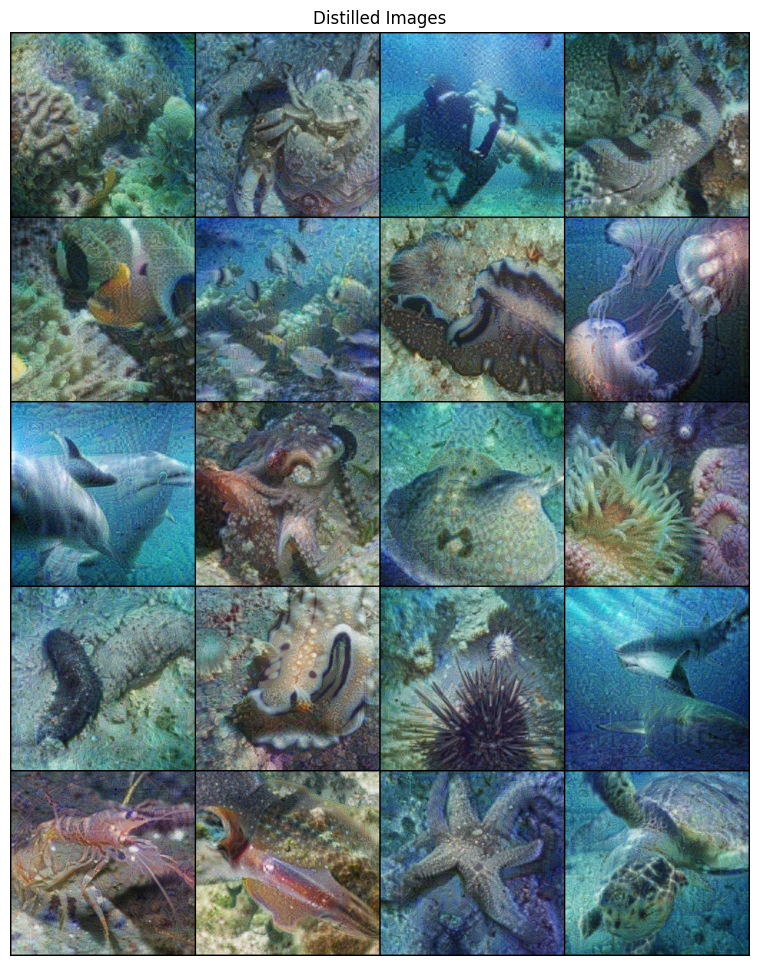

In [11]:
import torch
import matplotlib.pyplot as plt
import torchvision.utils as vutils

# Load
run_name = "dinov2_vitb_distill_252_ipc1_augs10_v100_32g"
data = torch.load(DISTILLED_PTH, weights_only=False)

print(f"Keys in data: {data.keys()}")

images = data["images"]  # (N, C, H, W)
print(f"Shape: {images.shape}")

# Display grid
grid = vutils.make_grid(images, nrow=4, padding=2)
plt.figure(figsize=(12, 12))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.title("Distilled Images")
plt.show()

In [ ]:
print(test_ds.class_to_idx)

{'coral': 0, 'crab': 1, 'diver': 2, 'eel': 3, 'fish': 4, 'fishInGroups': 5, 'flatworm': 6, 'jellyfish': 7, 'marine_dolphin': 8, 'octopus': 9, 'rayfish': 10, 'seaAnemone': 11, 'seaCucumber': 12, 'seaSlug': 13, 'seaUrchin': 14, 'shark': 15, 'shrimp': 16, 'squid': 17, 'starfish': 18, 'turtle': 19}


In [12]:
cnn_distill = simpleCNN(num_classes=20, depth=5).to(DEVICE)
optimizer = torch.optim.Adam(cnn_distill.parameters(), lr=1e-3)
lossfn = nn.CrossEntropyLoss()

In [13]:
print("Training...")
history_cnn_distill = {'train_loss':[], 'train_acc':[], 'test_loss':[], 'test_acc':[]}

for epoch in range(10):
    train_loss, train_acc = train_epoch(cnn_distill, distill_loader, optimizer, lossfn, DEVICE)
    test_loss, test_acc = evaluate(cnn_distill, test_loader, lossfn, DEVICE)
    history_cnn_distill['train_loss'].append(train_loss)
    history_cnn_distill['train_acc'].append(train_acc)
    history_cnn_distill['test_loss'].append(test_loss)
    history_cnn_distill['test_acc'].append(test_acc)
    print(f"Epoch {epoch+1}/10 - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

Training...


train:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1/10 - Train Loss: 3.0765, Train Acc: 0.1000, Test Loss: 3.0010, Test Acc: 0.0540


train:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 2/10 - Train Loss: 1.7467, Train Acc: 1.0000, Test Loss: 2.9496, Test Acc: 0.0825


...

Epoch 8/10 - Train Loss: 0.0018, Train Acc: 1.0000, Test Loss: 3.4656, Test Acc: 0.0676


train:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 9/10 - Train Loss: 0.0010, Train Acc: 1.0000, Test Loss: 3.5513, Test Acc: 0.0676


train:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 10/10 - Train Loss: 0.0006, Train Acc: 1.0000, Test Loss: 3.6310, Test Acc: 0.0682


In [ ]:
print(images_d.min(), images_d.max(), images_d.mean(), images_d.std())


tensor(0.0590, device='cuda:0') tensor(0.9206, device='cuda:0') tensor(0.4372, device='cuda:0') tensor(0.1428, device='cuda:0')


In [ ]:
x, _ = next(iter(test_loader))
print(x.min(), x.max(), x.mean(), x.std())

tensor(-2.1179) tensor(2.6400) tensor(-0.1380) tensor(1.1329)
